# 1. Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import json

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, f1_score
)

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

d:\Tugas Besar ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. load dataset

In [2]:
df = pd.read_csv('../data/predictive_maintenance.csv')

print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTarget Distribution:")
print(df['Target'].value_counts())
print("\nTarget Ratio:")
print(df['Target'].value_counts(normalize=True).round(3))
df.head()

Shape: (10000, 10)

Missing Values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

Target Distribution:
Target
0    9661
1     339
Name: count, dtype: int64

Target Ratio:
Target
0    0.966
1    0.034
Name: proportion, dtype: float64


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


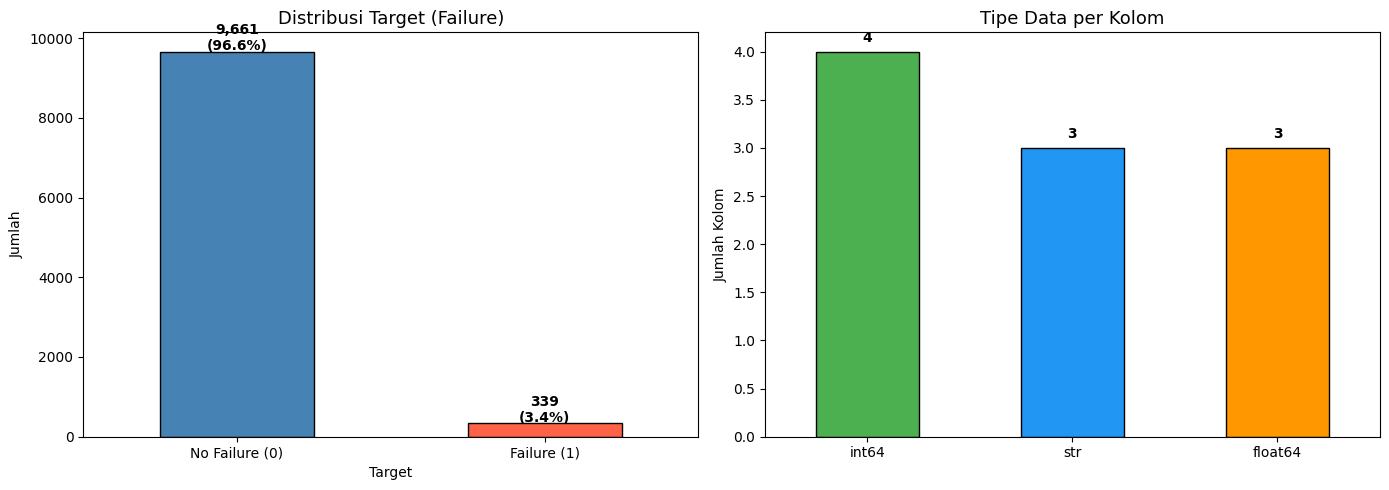

In [3]:
# Distribusi target & tipe data

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Target'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'],
    edgecolor='black'
)
axes[0].set_title('Distribusi Target (Failure)', fontsize=13)
axes[0].set_xticklabels(['No Failure (0)', 'Failure (1)'], rotation=0)
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(df['Target'].value_counts()):
    axes[0].text(i, v + 30, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')

dtype_counts = df.dtypes.value_counts()
dtype_counts.plot(
    kind='bar', ax=axes[1],
    color=['#4CAF50', '#2196F3', '#FF9800'],
    edgecolor='black'
)
axes[1].set_title('Tipe Data per Kolom', fontsize=13)
axes[1].set_xticklabels([str(x) for x in dtype_counts.index], rotation=0)
axes[1].set_ylabel('Jumlah Kolom')
for i, v in enumerate(dtype_counts):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

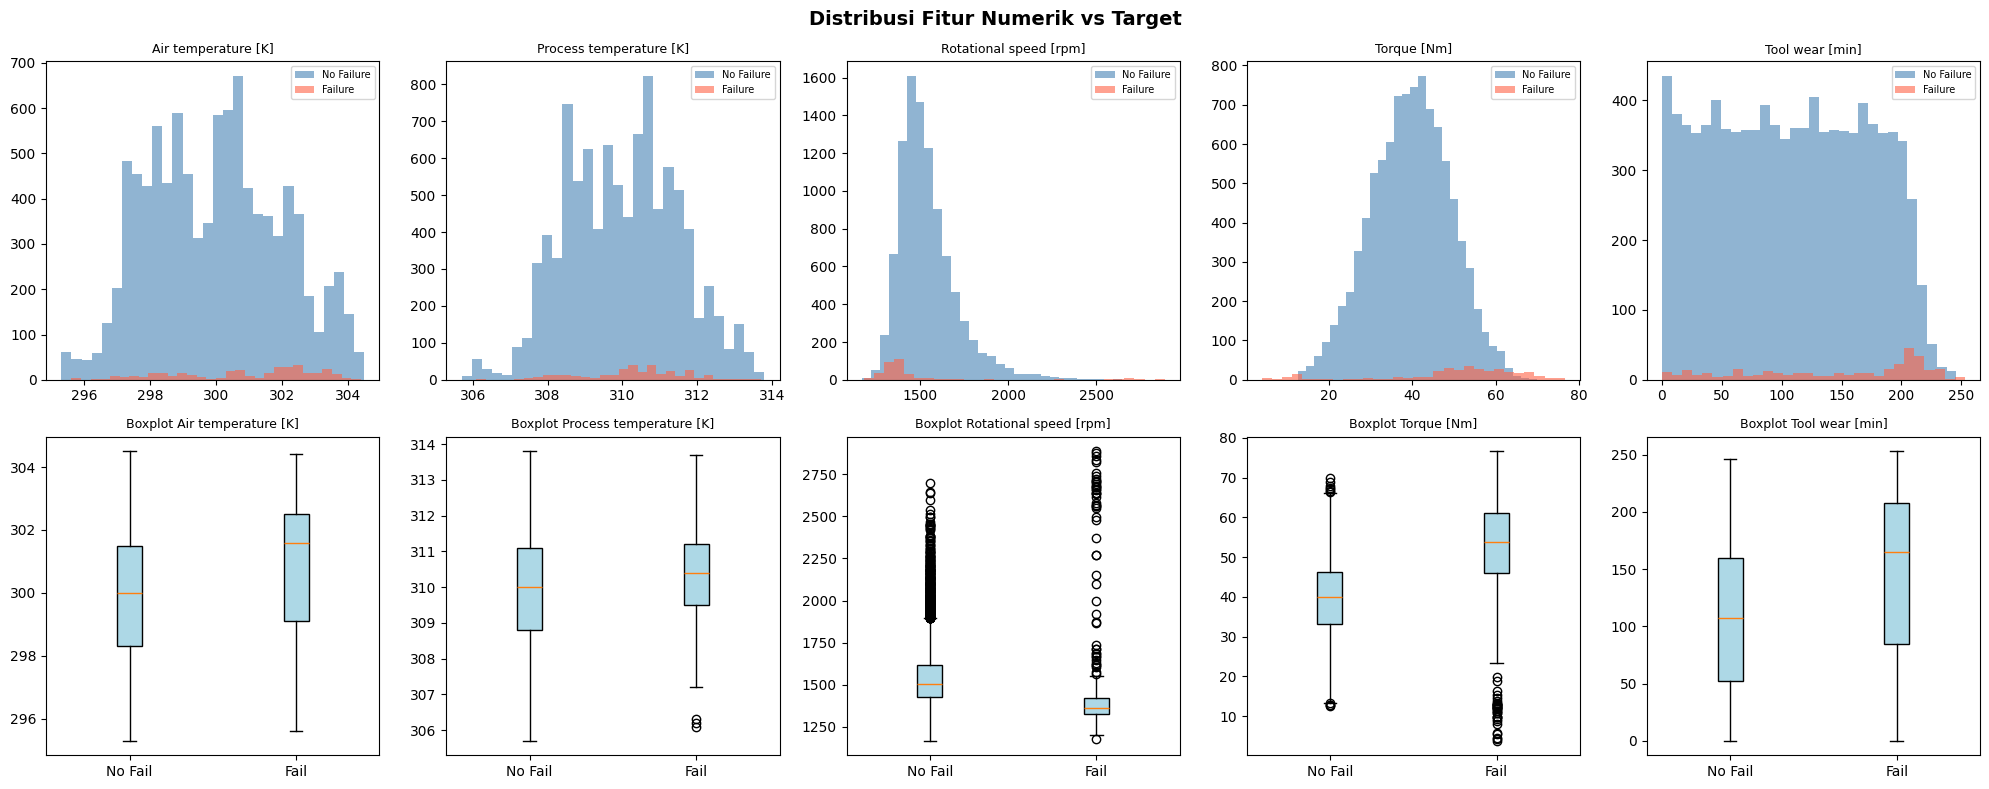

In [4]:
# Distribusi fitur numerik vs target

num_cols_viz = ['Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

n = len(num_cols_viz)
fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

for i, col in enumerate(num_cols_viz):
    axes[0][i].hist(
        df[df['Target'] == 0][col].dropna(),
        alpha=0.6, color='steelblue', label='No Failure', bins=30
    )
    axes[0][i].hist(
        df[df['Target'] == 1][col].dropna(),
        alpha=0.6, color='tomato', label='Failure', bins=30
    )
    axes[0][i].set_title(f'{col}', fontsize=9)
    axes[0][i].legend(fontsize=7)

    data_plot = [
        df[df['Target'] == 0][col].dropna(),
        df[df['Target'] == 1][col].dropna()
    ]
    axes[1][i].boxplot(data_plot, labels=['No Fail', 'Fail'],
                       patch_artist=True,
                       boxprops=dict(facecolor='lightblue'))
    axes[1][i].set_title(f'Boxplot {col}', fontsize=9)

plt.suptitle('Distribusi Fitur Numerik vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

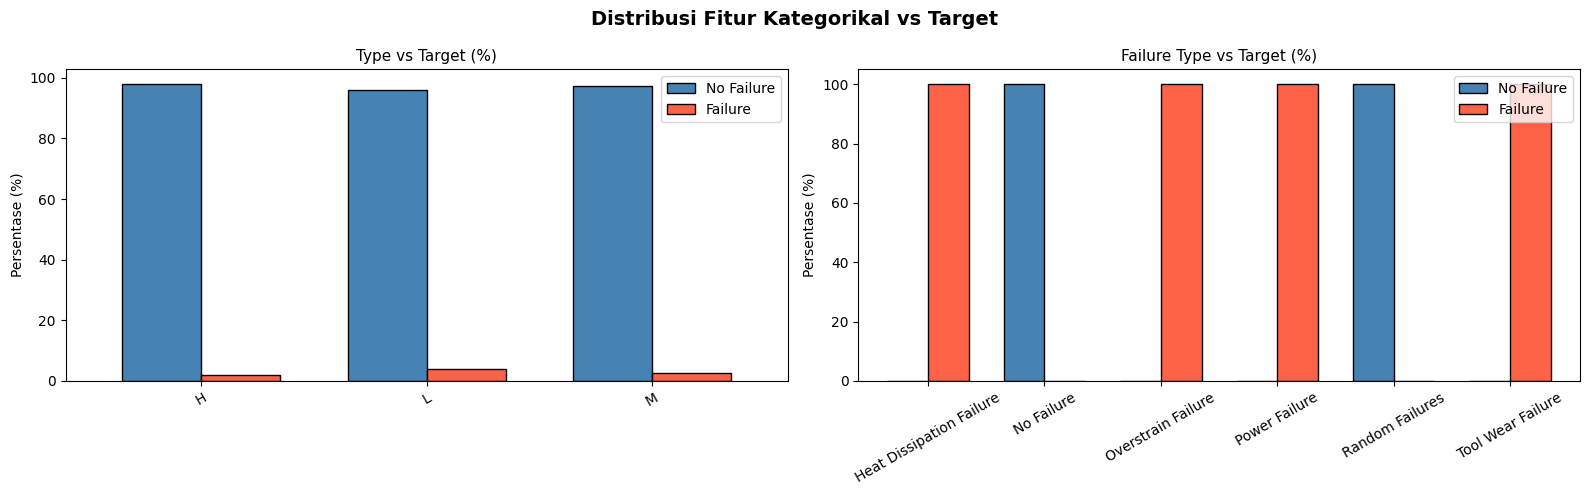

In [5]:
# Distribusi fitur kategorikal vs target

cat_cols_viz = ['Type', 'Failure Type']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, col in enumerate(cat_cols_viz):
    ct = pd.crosstab(df[col], df['Target'], normalize='index') * 100
    ct.plot(
        kind='bar', ax=axes[i],
        color=['steelblue', 'tomato'],
        edgecolor='black', width=0.7
    )
    axes[i].set_title(f'{col} vs Target (%)', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Persentase (%)')
    axes[i].legend(['No Failure', 'Failure'])
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Distribusi Fitur Kategorikal vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

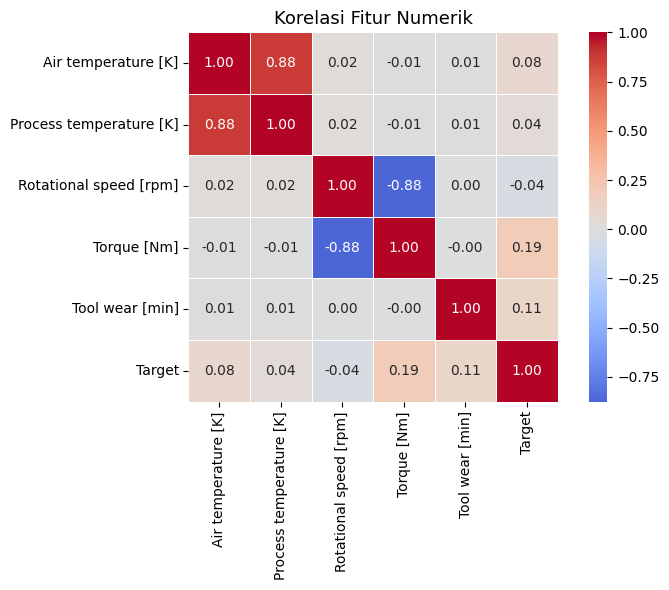

Insight korelasi dengan Target:
  Rotational speed [rpm]       → -0.044 (negatif)
  Process temperature [K]      → +0.036 (positif)
  Air temperature [K]          → +0.083 (positif)
  Tool wear [min]              → +0.105 (positif)
  Torque [Nm]                  → +0.191 (positif)


In [6]:
# Korelasi numerik

corr_cols = ['Air temperature [K]', 'Process temperature [K]',
             'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, ax=ax,
    linewidths=0.5
)
ax.set_title('Korelasi Fitur Numerik', fontsize=13)
plt.tight_layout()
plt.show()

print("Insight korelasi dengan Target:")
corr_t = corr_matrix['Target'].drop('Target').sort_values()
for col, val in corr_t.items():
    arah = "positif" if val > 0 else "negatif"
    print(f"  {col:28s} → {val:+.3f} ({arah})")

In [7]:
#ringkasan EDA
print("=" * 50)
print("RINGKASAN EDA")
print("=" * 50)
print(f"""
Dataset   : Predictive Maintenance (AI4I 2020)
Baris     : {df.shape[0]:,}
Kolom     : {df.shape[1]}
Duplikat  : {df.duplicated().sum()}

Target:
  No Failure (0) : {(df['Target']==0).sum():,} ({(df['Target']==0).mean()*100:.1f}%)
  Failure   (1)  : {(df['Target']==1).sum():,} ({(df['Target']==1).mean()*100:.1f}%)
  → Dataset SANGAT IMBALANCED

Missing Values:
  Tidak ada missing values

Tipe Data:
  Numerik (int/float) : {df.select_dtypes(include=['int64','float64']).shape[1]} kolom
  Kategorikal (object): {df.select_dtypes(include='object').shape[1]} kolom

Insight Utama:
  - Torque tinggi + rpm rendah → indikasi overstrain
  - Tool wear tinggi → risiko kegagalan naik
  - Selisih suhu proses-udara → indikasi heat dissipation failure
""")

RINGKASAN EDA

Dataset   : Predictive Maintenance (AI4I 2020)
Baris     : 10,000
Kolom     : 10
Duplikat  : 0

Target:
  No Failure (0) : 9,661 (96.6%)
  Failure   (1)  : 339 (3.4%)
  → Dataset SANGAT IMBALANCED

Missing Values:
  Tidak ada missing values

Tipe Data:
  Numerik (int/float) : 7 kolom
  Kategorikal (object): 3 kolom

Insight Utama:
  - Torque tinggi + rpm rendah → indikasi overstrain
  - Tool wear tinggi → risiko kegagalan naik
  - Selisih suhu proses-udara → indikasi heat dissipation failure



# 3. Feature dan Label

In [8]:
# ngedrop kolom non-prediktif & kolom bocoran target 
df = df.drop(columns=['UDI', 'Product ID', 'Failure Type'])

# misahin feature dan label
X = df.drop(columns=['Target'])
y = df['Target']

print("Features:", X.columns.tolist())
print("Total fitur:", X.shape[1])
print("Label values:", y.unique())
print("Label distribution:", y.value_counts().to_dict())

Features: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Total fitur: 6
Label values: [0 1]
Label distribution: {0: 9661, 1: 339}


# 4. Split Dataset

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("Distribusi y_train:")
print(y_train.value_counts(normalize=True).round(3))
print("Distribusi y_val:")
print(y_val.value_counts(normalize=True).round(3))

X_train: (8000, 6)
X_val  : (2000, 6)
Distribusi y_train:
Target
0    0.966
1    0.034
Name: proportion, dtype: float64
Distribusi y_val:
Target
0    0.966
1    0.034
Name: proportion, dtype: float64


# 5. Preprocessing

In [10]:
rename_map = {
    'Air temperature [K]'     : 'air_temp',
    'Process temperature [K]' : 'process_temp',
    'Rotational speed [rpm]'  : 'rot_speed',
    'Torque [Nm]'             : 'torque',
    'Tool wear [min]'         : 'tool_wear'
}
X_train = X_train.rename(columns=rename_map)
X_val   = X_val.rename(columns=rename_map)

# Label Encoding kolom kategorikal (Type)
cat_cols = ['Type']
print("Kolom kategorikal:", cat_cols)

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_val[col]   = le.transform(X_val[col].astype(str))
    le_dict[col] = le


# (indikasi heat dissipation failure)
X_train['temp_diff'] = X_train['process_temp'] - X_train['air_temp']
X_val['temp_diff']   = X_val['process_temp'] - X_val['air_temp']

# (proxy power failure)
X_train['power'] = X_train['torque'] * X_train['rot_speed']
X_val['power']   = X_val['torque'] * X_val['rot_speed']

# (proxy overstrain failure)
X_train['strain'] = X_train['tool_wear'] * X_train['torque']
X_val['strain']   = X_val['tool_wear'] * X_val['torque']

# Feature Scaling kolom numerik
num_cols = ['air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear',
            'temp_diff', 'power', 'strain']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols]   = scaler.transform(X_val[num_cols])

print("Preprocessing selesai")
print("Total fitur:", X_train.shape[1])
print("Kolom:", X_train.columns.tolist())

Kolom kategorikal: ['Type']
Preprocessing selesai
Total fitur: 9
Kolom: ['Type', 'air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear', 'temp_diff', 'power', 'strain']


# 6. Handling Imbalance dan Classifier

In [11]:
print("Sebelum SMOTE:", y_train.value_counts().to_dict())

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Sesudah SMOTE:", pd.Series(y_train_res).value_counts().to_dict())

classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
print("\n✅ Classifier siap:", classifier)

Sebelum SMOTE: {0: 7729, 1: 271}
Sesudah SMOTE: {0: 7729, 1: 7729}

✅ Classifier siap: RandomForestClassifier(n_jobs=-1, random_state=42)


# 7. Training dan Hyperparameter

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 600),
        'max_depth'        : trial.suggest_int('max_depth', 8, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 15),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight'     : trial.suggest_categorical('class_weight', ['balanced', None]),
    }
    rf = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    score = cross_val_score(rf, X_train_res, y_train_res,
                            cv=cv, scoring='roc_auc', n_jobs=-1).mean()
    return score

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n Best ROC-AUC (CV): {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

best_rf = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train_res, y_train_res)
print("\n Model selesai ditraining")

Best trial: 49. Best value: 0.99933: 100%|██████████| 50/50 [02:44<00:00,  3.28s/it] 



 Best ROC-AUC (CV): 0.9993
Best params: {'n_estimators': 206, 'max_depth': 18, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': None}

 Model selesai ditraining


# 8. Akurasi dan Threshold

In [13]:
y_proba = best_rf.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.01)
best_thresh, best_f1 = 0.5, 0

for thresh in thresholds:
    y_pred_t = (y_proba >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred_t, average='macro')
    if f1 > best_f1:
        best_f1     = f1
        best_thresh = thresh

y_pred = (y_proba >= best_thresh).astype(int)

print("=== AKURASI MODEL ===")
print(f"Accuracy         : {accuracy_score(y_val, y_pred):.4f}")
print(f"ROC-AUC          : {roc_auc_score(y_val, y_proba):.4f}")
print(f"Macro F1         : {f1_score(y_val, y_pred, average='macro'):.4f}")
print(f"Threshold optimal: {best_thresh:.2f}")

=== AKURASI MODEL ===
Accuracy         : 0.9885
ROC-AUC          : 0.9843
Macro F1         : 0.9118
Threshold optimal: 0.67


# 9. Confusion Matrix

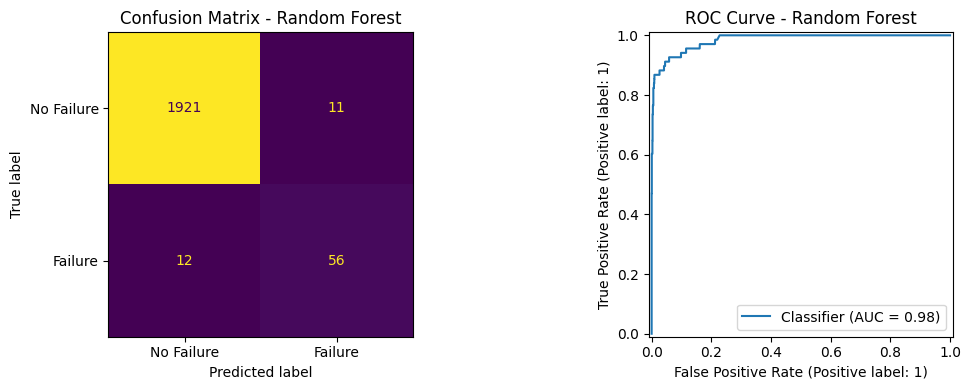

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred,
    display_labels=['No Failure', 'Failure'],
    ax=axes[0], colorbar=False
)
axes[0].set_title('Confusion Matrix - Random Forest')

RocCurveDisplay.from_predictions(y_val, y_proba, ax=axes[1])
axes[1].set_title('ROC Curve - Random Forest')

plt.tight_layout()
plt.show()

# 10. Detail Perbandingan

In [15]:
baseline_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
baseline_rf.fit(X_train_res, y_train_res)
y_proba_base = baseline_rf.predict_proba(X_val)[:, 1]
y_pred_base  = (y_proba_base >= 0.5).astype(int)

print("=== DETAIL HASIL PERBANDINGAN ===\n")
print("── Baseline Random Forest ──")
print(classification_report(y_val, y_pred_base, target_names=['No Failure', 'Failure']))
print(f"ROC-AUC  : {roc_auc_score(y_val, y_proba_base):.4f}")
print(f"Macro F1 : {f1_score(y_val, y_pred_base, average='macro'):.4f}")

print("\n── Tuned Random Forest ──")
print(classification_report(y_val, y_pred, target_names=['No Failure', 'Failure']))
print(f"ROC-AUC  : {roc_auc_score(y_val, y_proba):.4f}")
print(f"Macro F1 : {f1_score(y_val, y_pred, average='macro'):.4f}")

print("\n── Ringkasan ──")
cm_base = confusion_matrix(y_val, y_pred_base)
cm_tune = confusion_matrix(y_val, y_pred)

summary = pd.DataFrame({
    'Metrik'  : ['Accuracy', 'ROC-AUC', 'Macro F1', 'F1 Failure', 'Recall Failure', 'Threshold'],
    'Baseline': [
        round(accuracy_score(y_val, y_pred_base), 4),
        round(roc_auc_score(y_val, y_proba_base), 4),
        round(f1_score(y_val, y_pred_base, average='macro'), 4),
        round(f1_score(y_val, y_pred_base, average=None)[1], 4),
        round(cm_base[1][1] / cm_base[1].sum(), 4),
        0.50
    ],
    'Tuned'   : [
        round(accuracy_score(y_val, y_pred), 4),
        round(roc_auc_score(y_val, y_proba), 4),
        round(f1_score(y_val, y_pred, average='macro'), 4),
        round(f1_score(y_val, y_pred, average=None)[1], 4),
        round(cm_tune[1][1] / cm_tune[1].sum(), 4),
        round(best_thresh, 2)
    ]
})
print(summary.to_string(index=False))

=== DETAIL HASIL PERBANDINGAN ===

── Baseline Random Forest ──
              precision    recall  f1-score   support

  No Failure       1.00      0.98      0.99      1932
     Failure       0.63      0.87      0.73        68

    accuracy                           0.98      2000
   macro avg       0.81      0.93      0.86      2000
weighted avg       0.98      0.98      0.98      2000

ROC-AUC  : 0.9818
Macro F1 : 0.8609

── Tuned Random Forest ──
              precision    recall  f1-score   support

  No Failure       0.99      0.99      0.99      1932
     Failure       0.84      0.82      0.83        68

    accuracy                           0.99      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.99      0.99      0.99      2000

ROC-AUC  : 0.9843
Macro F1 : 0.9118

── Ringkasan ──
        Metrik  Baseline  Tuned
      Accuracy    0.9785 0.9885
       ROC-AUC    0.9818 0.9843
      Macro F1    0.8609 0.9118
    F1 Failure    0.7329 0.8296
Recall

# 11.  Coba V2

In [16]:
best_rf_v2 = RandomForestClassifier(
    n_estimators=427, max_depth=12, min_samples_split=2,
    min_samples_leaf=2, max_features='log2',
    class_weight='balanced', random_state=42, n_jobs=-1
)
best_rf_v2.fit(X_train_res, y_train_res)
y_proba_v2 = best_rf_v2.predict_proba(X_val)[:, 1]

best_thresh_v2, best_f1_v2 = 0.5, 0
for thresh in np.arange(0.1, 0.9, 0.01):
    y_pred_t = (y_proba_v2 >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred_t, average='macro')
    if f1 > best_f1_v2:
        best_f1_v2     = f1
        best_thresh_v2 = thresh

y_pred_v2 = (y_proba_v2 >= best_thresh_v2).astype(int)
cm_v2     = confusion_matrix(y_val, y_pred_v2)

print("=== PERBANDINGAN ===")
print(f"{'Metrik':<20} {'Tuned v1':>10} {'Tuned v2':>10}")
print(f"{'ROC-AUC':<20} {roc_auc_score(y_val, y_proba):>10.4f} {roc_auc_score(y_val, y_proba_v2):>10.4f}")
print(f"{'Macro F1':<20} {best_f1:>10.4f} {best_f1_v2:>10.4f}")
print(f"{'Recall Failure':<20} {cm_tune[1][1]/cm_tune[1].sum():>10.4f} {cm_v2[1][1]/cm_v2[1].sum():>10.4f}")
print(f"{'Threshold':<20} {best_thresh:>10.2f} {best_thresh_v2:>10.2f}")

=== PERBANDINGAN ===
Metrik                 Tuned v1   Tuned v2
ROC-AUC                  0.9843     0.9847
Macro F1                 0.9118     0.9163
Recall Failure           0.8235     0.8382
Threshold                  0.67       0.71


# 12. Feature Engineering final


In [17]:
def add_pm_features(df):
    df = df.copy()
    df['overstrain'] = ((df['tool_wear'] > 0) & (df['torque'] > 0)).astype(int)
    df['power_risk'] = ((df['power'] > 0) & (df['torque'] > 0)).astype(int)
    df['heat_risk'] = (df['temp_diff'] < 0).astype(int)
    df['torque_speed_ratio'] = df['torque'] / (df['rot_speed'] + 0.001)
    return df

X_train_fe = add_pm_features(X_train_res)
X_val_fe   = add_pm_features(X_val)

print("Total fitur:", X_train_fe.shape[1])
print("Fitur baru:", [c for c in X_train_fe.columns if c not in X_train_res.columns])

best_rf_fe = RandomForestClassifier(
    n_estimators=427, max_depth=12, min_samples_split=2,
    min_samples_leaf=2, max_features='log2',
    class_weight='balanced', random_state=42, n_jobs=-1
)
best_rf_fe.fit(X_train_fe, y_train_res)
y_proba_fe = best_rf_fe.predict_proba(X_val_fe)[:, 1]

best_thresh_fe, best_f1_fe = 0.5, 0
for thresh in np.arange(0.1, 0.9, 0.01):
    y_pred_t = (y_proba_fe >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred_t, average='macro')
    if f1 > best_f1_fe:
        best_f1_fe     = f1
        best_thresh_fe = thresh

y_pred_fe = (y_proba_fe >= best_thresh_fe).astype(int)
cm_fe     = confusion_matrix(y_val, y_pred_fe)

print("\n=== PERBANDINGAN ===")
print(f"{'Metrik':<20} {'v2':>10} {'FE':>10}")
print(f"{'ROC-AUC':<20} {roc_auc_score(y_val, y_proba_v2):>10.4f} {roc_auc_score(y_val, y_proba_fe):>10.4f}")
print(f"{'Macro F1':<20} {best_f1_v2:>10.4f} {f1_score(y_val, y_pred_fe, average='macro'):>10.4f}")
print(f"{'Recall Failure':<20} {cm_v2[1][1]/cm_v2[1].sum():>10.4f} {cm_fe[1][1]/cm_fe[1].sum():>10.4f}")
print(f"{'Threshold':<20} {best_thresh_v2:>10.2f} {best_thresh_fe:>10.2f}")

Total fitur: 13
Fitur baru: ['overstrain', 'power_risk', 'heat_risk', 'torque_speed_ratio']

=== PERBANDINGAN ===
Metrik                       v2         FE
ROC-AUC                  0.9847     0.9831
Macro F1                 0.9163     0.8996
Recall Failure           0.8382     0.7941
Threshold                  0.71       0.68


In [18]:
# cek overfitting
from sklearn.model_selection import cross_val_score

print("=" * 55)
print("🔍 PEMERIKSAAN OVERFITTING - Tuned v2")
print("=" * 55)

# 1. Bandingkan skor TRAIN vs VALIDATION
y_proba_tr = best_rf_v2.predict_proba(X_train_res)[:, 1]
y_pred_tr  = (y_proba_tr >= best_thresh_v2).astype(int)

train_auc = roc_auc_score(y_train_res, y_proba_tr)
val_auc   = roc_auc_score(y_val, y_proba_v2)
train_f1  = f1_score(y_train_res, y_pred_tr, average='macro')
val_f1    = f1_score(y_val, y_pred_v2, average='macro')

print(f"\n{'Metrik':<15} {'Train':>10} {'Val':>10} {'Gap':>10}")
print(f"{'ROC-AUC':<15} {train_auc:>10.4f} {val_auc:>10.4f} {train_auc-val_auc:>10.4f}")
print(f"{'Macro F1':<15} {train_f1:>10.4f} {val_f1:>10.4f} {train_f1-val_f1:>10.4f}")

# 2. Cross-validation pada data training (cek stabilitas)
cv_scores = cross_val_score(
    best_rf_v2, X_train_res, y_train_res,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)
print(f"\nCV ROC-AUC (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Skor per fold      : {np.round(cv_scores, 4)}")

# 3. Interpretasi otomatis
gap_auc = train_auc - val_auc
print("\n" + "=" * 55)
if gap_auc > 0.05:
    print("INDIKASI OVERFIT — gap Train-Val ROC-AUC > 0.05")
elif gap_auc > 0.02:
    print("SEDIKIT OVERFIT — gap kecil, masih wajar")
else:
    print("TIDAK OVERFIT — gap Train-Val sangat kecil")
print(f"   Gap ROC-AUC = {gap_auc:.4f}")
print("=" * 55)

🔍 PEMERIKSAAN OVERFITTING - Tuned v2

Metrik               Train        Val        Gap
ROC-AUC             0.9999     0.9847     0.0152
Macro F1            0.9899     0.9163     0.0736

CV ROC-AUC (5-fold): 0.9988 ± 0.0002
Skor per fold      : [0.9989 0.9986 0.9986 0.9989 0.9991]

TIDAK OVERFIT — gap Train-Val sangat kecil
   Gap ROC-AUC = 0.0152


# 13. Simpan Model

In [20]:
os.makedirs('../models', exist_ok=True)

joblib.dump(best_rf_v2, '../models/rf_model.pkl')
joblib.dump(scaler, '../models/rf_scaler.pkl')
joblib.dump(le_dict, '../models/rf_label_encoders.pkl')

feature_names = X_train_res.columns.tolist()
joblib.dump(feature_names, '../models/rf_selected_features.pkl')

with open('../models/best_params_rf.json', 'w') as f:
    json.dump({
        'n_estimators': 427, 'max_depth': 12, 'min_samples_split': 2,
        'min_samples_leaf': 2, 'max_features': 'log2', 'class_weight': 'balanced'
    }, f, indent=2)

joblib.dump({
    'n_features'   : X_train_res.shape[1],
    'feature_names': feature_names,
    'model_version': 'RF+Tuned-v2+PredictiveMaintenance',
    'auc'          : round(roc_auc_score(y_val, y_proba_v2), 4),
    'macro_f1'     : round(best_f1_v2, 4),
    'threshold'    : round(best_thresh_v2, 2)
}, '../models/rf_model_metadata.pkl')

print("✅ Model final (v2) tersimpan!")
print(f"AUC       : {roc_auc_score(y_val, y_proba_v2):.4f}")
print(f"Macro F1  : {best_f1_v2:.4f}")
print(f"Threshold : {best_thresh_v2:.2f}")
print("Files:", os.listdir('../models'))

✅ Model final (v2) tersimpan!
AUC       : 0.9847
Macro F1  : 0.9163
Threshold : 0.71
Files: ['best_params_dt.json', 'best_params_knn.json', 'best_params_rf.json', 'best_params_svm.json', 'dt_model_maintenance.pkl', 'dt_preprocessor_maintenance.pkl', 'dt_selected_features_maintenance.pkl', 'knn_model_maintenance.pkl', 'knn_preprocessor_maintenance.pkl', 'knn_selected_features_maintenance.pkl', 'rf_label_encoders.pkl', 'rf_model.pkl', 'rf_model_metadata.pkl', 'rf_scaler.pkl', 'rf_selected_features.pkl', 'svm_model_maintenance.pkl', 'svm_preprocessor_maintenance.pkl', 'svm_selected_features_maintenance.pkl', 'X_columns.pkl']


# 14. Sanity Check


In [21]:
sample       = X_val.iloc[:5]
proba_sample = best_rf_v2.predict_proba(sample)[:, 1]
pred_sample  = (proba_sample >= best_thresh_v2).astype(int)

result = pd.DataFrame({
    'Actual'       : y_val.iloc[:5].values,
    'Predicted'    : pred_sample,
    'Prob(Failure)': proba_sample.round(3)
})
print("=== SANITY CHECK ===")
print(result)

=== SANITY CHECK ===
   Actual  Predicted  Prob(Failure)
0       0          0          0.358
1       0          0          0.001
2       0          1          0.769
3       0          0          0.000
4       0          0          0.098
